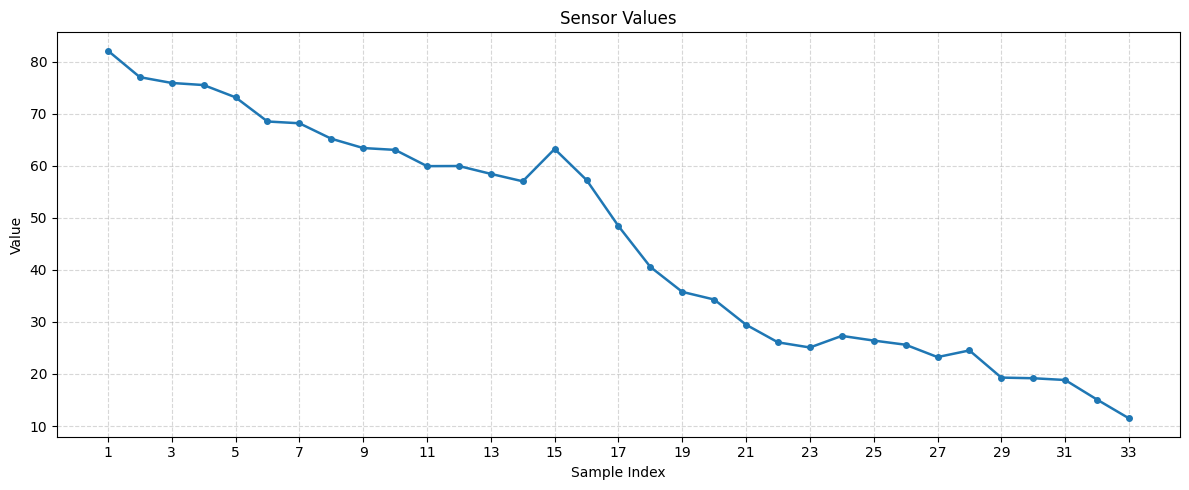

In [5]:
import matplotlib.pyplot as plt

values = [
    82.0718,
    76.9931,
    75.8793,
    75.4759,
    73.1170,
    68.4803,
    68.1380,
    65.1699,
    63.3804,
    63.0284,
    59.9043,
    59.9296,
    58.4216,
    56.9954,
    63.1981,
    57.2445,
    48.3960,
    40.5526,
    35.7585,
    34.2899,
    29.4515,
    26.0669,
    25.0799,
    27.3085,
    26.4092,
    25.6090,
    23.2370,
    24.5159,
    19.2986,
    19.1738,
    18.8365,
    15.0758,
    11.4737,
]

x = list(range(1, len(values) + 1))

plt.figure(figsize=(12, 5))
plt.plot(x, values, marker="o", linewidth=1.8, markersize=4)
plt.title("Sensor Values")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(range(1, len(values) + 1, 2))
plt.tight_layout()
plt.show()

Parsed 283 samples
RAW shape=(283, 4), F shape=(283, 4), V shape=(283, 2)


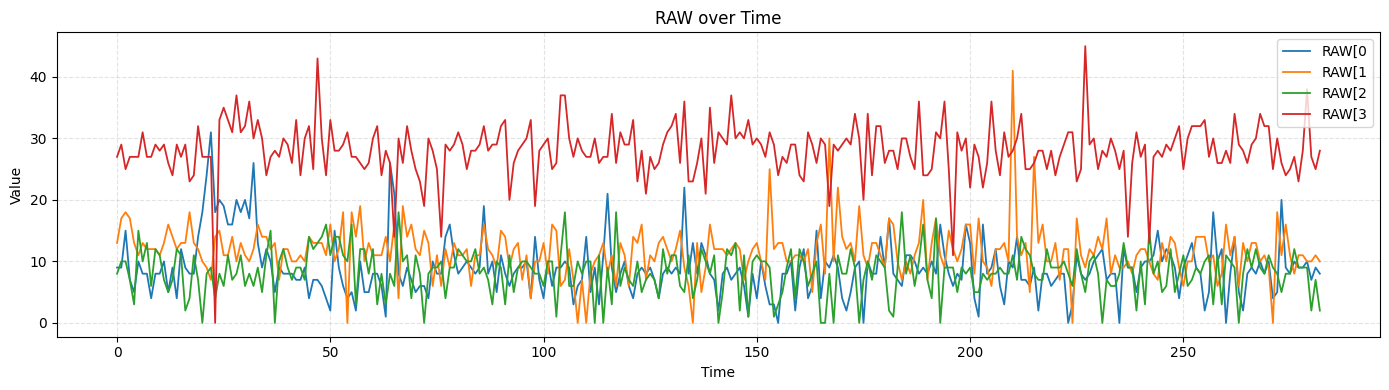

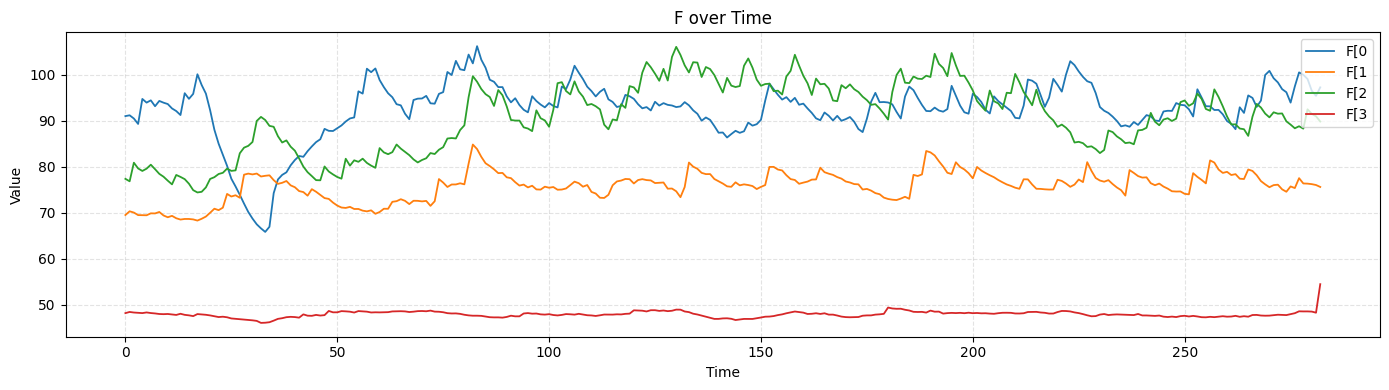

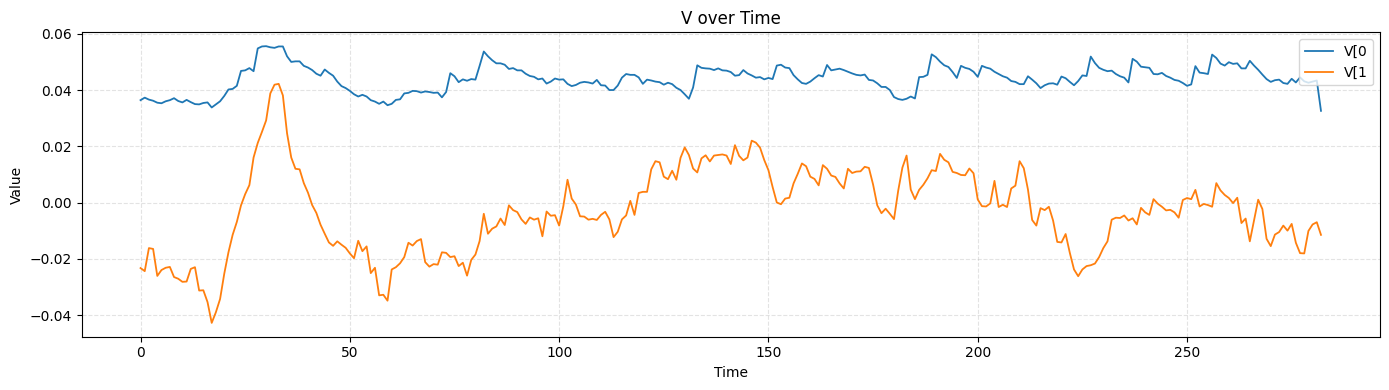

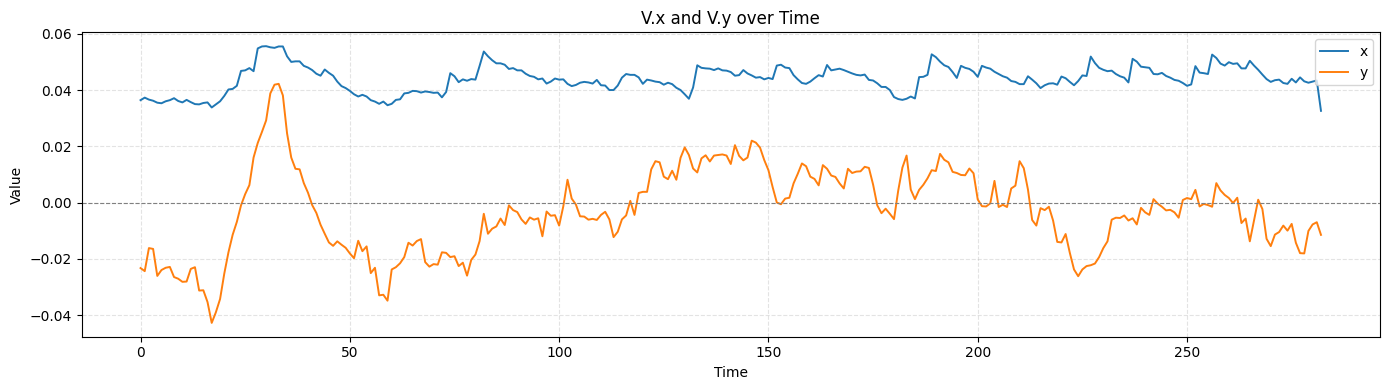

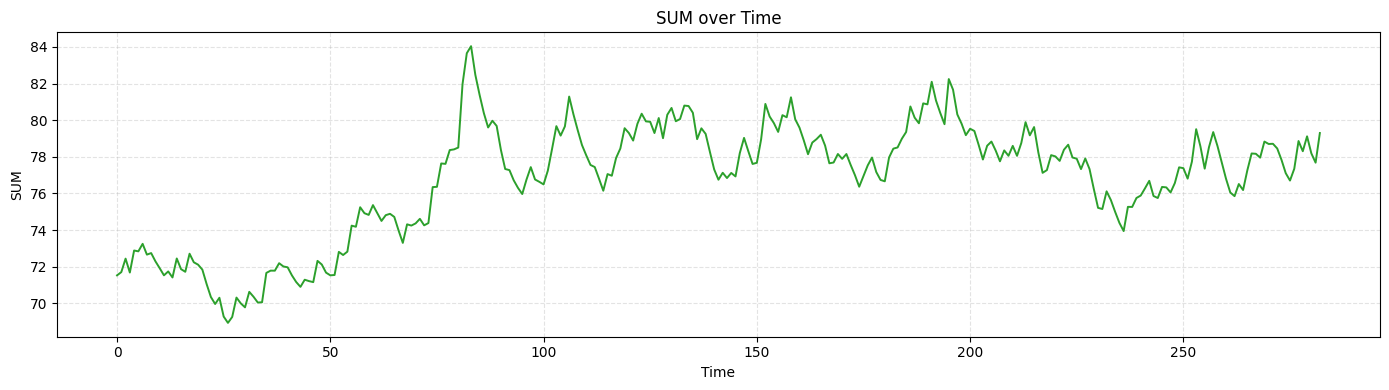

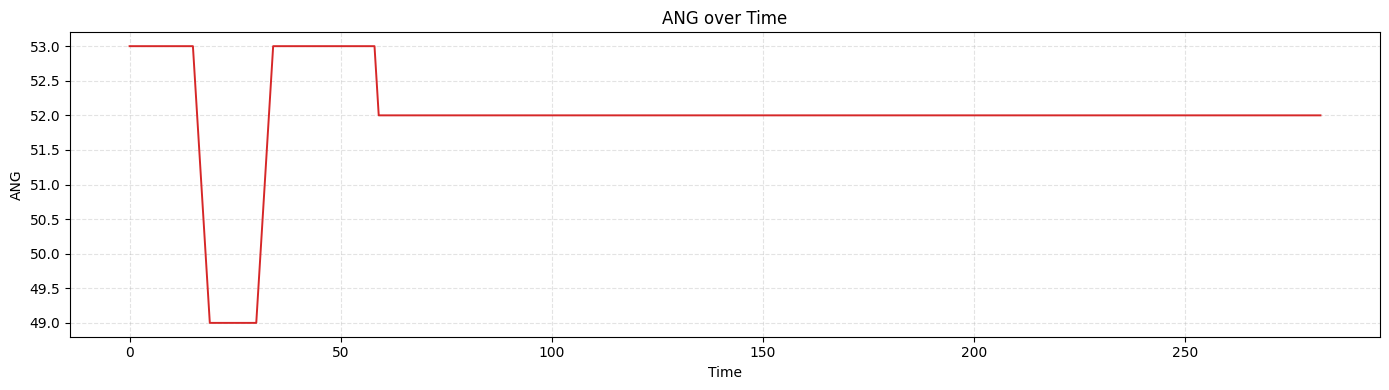

In [27]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# If one sample corresponds to fixed time (seconds), set dt (e.g., 0.01).
# Keep 1.0 to use sample index as time step.
dt = 1.0

data_path = Path("data.txt")
if not data_path.exists():
    raise FileNotFoundError(f"Cannot find {data_path.resolve()}")

line_pattern = re.compile(
    r"RAW=\[(?P<raw>[^\]]+)\]\s*"
    r"F=\[(?P<f>[^\]]+)\]\s*"
    r"V=\[(?P<v>[^\]]+)\]\s*"
    r"SUM=(?P<sum>[-+]?\d*\.?\d+)\s*"
    r"ANG=\s*(?P<ang>[-+]?\d*\.?\d+)"
)

def parse_vector(text):
    return [float(x) for x in text.split()]

raw_list, f_list, v_list, sum_list, ang_list = [], [], [], [], []
for line in data_path.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if not line:
        continue

    m = line_pattern.match(line)
    if not m:
        continue

    raw_vals = parse_vector(m.group("raw"))
    f_vals = parse_vector(m.group("f"))
    v_vals = parse_vector(m.group("v"))

    raw_list.append(raw_vals)
    f_list.append(f_vals)
    v_list.append(v_vals)
    sum_list.append(float(m.group("sum")))
    ang_list.append(float(m.group("ang")))

if not raw_list:
    raise ValueError("No valid lines were parsed from data.txt")

raw_arr = np.array(raw_list)
f_arr = np.array(f_list)
v_arr = np.array(v_list)
sum_arr = np.array(sum_list)
ang_arr = np.array(ang_list)

n = len(sum_arr)
t = np.arange(n) * dt

print(f"Parsed {n} samples")
print(f"RAW shape={raw_arr.shape}, F shape={f_arr.shape}, V shape={v_arr.shape}")

def plot_multichannel(time_axis, data, title, label_prefix):
    """Plot all channels on a single frame with different colors."""
    fig, ax = plt.subplots(figsize=(14, 4))
    channels = data.shape[1]
    for i in range(channels):
        ax.plot(time_axis, data[:, i], linewidth=1.3, label=f"{label_prefix}{i}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout()
    plt.show()

# RAW channels over time (all channels, single frame)
plot_multichannel(t, raw_arr, "RAW over Time", "RAW[")

# F channels over time (all channels, single frame)
plot_multichannel(t, f_arr, "F over Time", "F[")

# V components (x and y) over time (single frame)
plot_multichannel(t, v_arr, "V over Time", "V[")

# V.x and V.y over time (single frame, different colors)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, v_arr[:, 0], linewidth=1.4, color="tab:blue", label="x")
ax.plot(t, v_arr[:, 1], linewidth=1.4, color="tab:orange", label="y")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("V.x and V.y over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(loc="upper right")
ax.grid(True, linestyle="--", alpha=0.35)
fig.tight_layout()
plt.show()

# SUM over time
plt.figure(figsize=(14, 4))
plt.plot(t, sum_arr, linewidth=1.4, color="tab:green")
plt.title("SUM over Time")
plt.xlabel("Time")
plt.ylabel("SUM")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

# ANG over time
plt.figure(figsize=(14, 4))
plt.plot(t, ang_arr, linewidth=1.4, color="tab:red")
plt.title("ANG over Time")
plt.xlabel("Time")
plt.ylabel("ANG")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()
